<a href="https://colab.research.google.com/github/FrankArcosAnselmo/mI_lab01_Fa/blob/develop/Lab12_Arcos_Frank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.utils import resample
from scipy.stats import chi2

# Cargar el archivo
path = "/content/drive/MyDrive/BIG DATA Y CIENCIAS DE DATOS/MINERIA DE DATOS/obesidad.csv"
df = pd.read_csv(path)

# Mostrar las primeras filas
df.head()


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21,1.62,64.0,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight
1,Female,21,1.52,56.0,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23,1.80,77.0,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight
3,Male,27,1.80,87.0,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I
4,Male,22,1.78,89.8,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II


### a. Realice el preprocesamiento de la información que incluya el análisis de datos faltantes,tratamiento de outliers a nivel univariado y multivariado, y balanceo de clases.

In [ ]:
print("Valores faltantes por columna:\n", df.isnull().sum())

Valores faltantes por columna:
 Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64


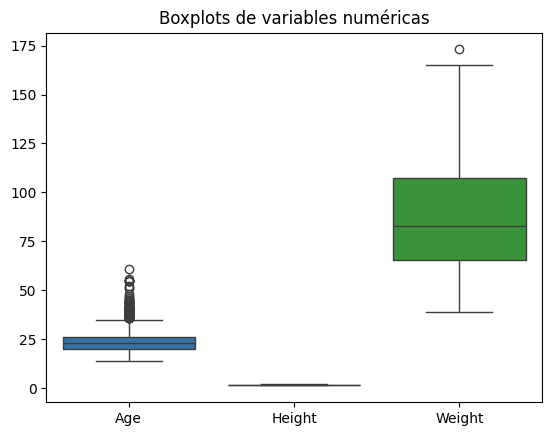

In [ ]:
sns.boxplot(data=df[['Age', 'Height', 'Weight']])
plt.title('Boxplots de variables numéricas')
plt.show()

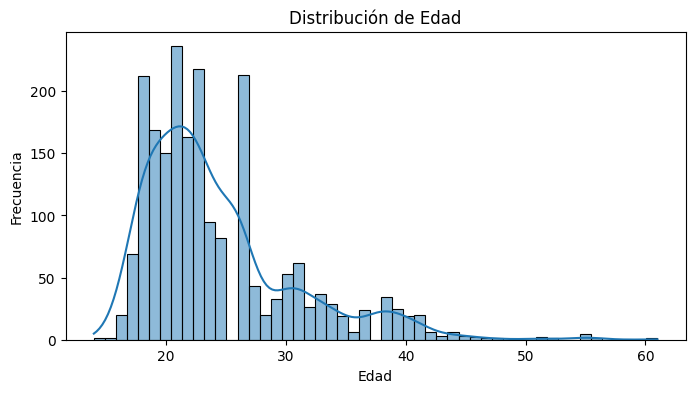

In [ ]:
# Distribución de edad
plt.figure(figsize=(8, 4))
sns.histplot(df['Age'], kde=True)
plt.title('Distribución de Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

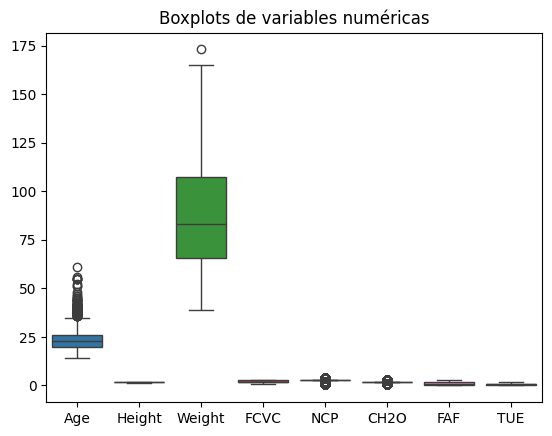

In [ ]:
# prompt: saca boxplots de valores numericos

numeric_cols = df.select_dtypes(include=np.number).columns
sns.boxplot(data=df[numeric_cols])
plt.title('Boxplots de variables numéricas')
plt.show()

In [ ]:
from numpy.linalg import inv

def mahalanobis_distance(df, cols):
    data = df[cols].dropna()
    mean = data.mean().values
    cov = np.cov(data.values.T)
    inv_cov = inv(cov)
    dists = []
    for _, row in data.iterrows():
        diff = row.values - mean
        dist = np.sqrt(np.dot(np.dot(diff.T, inv_cov), diff))
        dists.append(dist)
    return dists

df['mahal_dist'] = mahalanobis_distance(df, ['Age', 'Height', 'Weight'])
threshold = chi2.ppf(0.95, df=3)
outliers = df[df['mahal_dist'] > threshold]
print("Número de outliers multivariantes:", len(outliers))
df = df[df['mahal_dist'] <= threshold].drop(columns='mahal_dist')


Número de outliers multivariantes: 0


In [ ]:
print(df.columns.tolist())


['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad']


In [ ]:
print(df.head())
print(df.columns)
print(df.info())

   Gender  Age  Height  Weight family_history_with_overweight FAVC  FCVC  NCP  \
0  Female   21    1.62    64.0                            yes   no     2    3   
1  Female   21    1.52    56.0                            yes   no     3    3   
2    Male   23    1.80    77.0                            yes   no     2    3   
3    Male   27    1.80    87.0                             no   no     3    3   
4    Male   22    1.78    89.8                             no   no     2    1   

        CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC                 MTRANS  \
0  Sometimes    no     2   no    0    1          no  Public_Transportation   
1  Sometimes   yes     3  yes    3    0   Sometimes  Public_Transportation   
2  Sometimes    no     2   no    2    1  Frequently  Public_Transportation   
3  Sometimes    no     2   no    2    0  Frequently                Walking   
4  Sometimes    no     2   no    0    0   Sometimes  Public_Transportation   

            NObeyesdad  
0        Normal_Wei

In [ ]:
#BALANCEO DE CLASES
# Asegúrate de que la columna objetivo sea de tipo string (por si acaso)
df['NObeyesdad'] = df['NObeyesdad'].astype(str)

# Mostrar distribución original
print("Distribución antes del balanceo:\n", df['NObeyesdad'].value_counts())

# Encontrar clase minoritaria
min_count = df['NObeyesdad'].value_counts().min()

# Balancear usando submuestreo
df_bal = pd.concat([
    resample(df[df['NObeyesdad'] == cls], replace=False, n_samples=min_count, random_state=0)
    for cls in df['NObeyesdad'].unique()
])

print("Distribución después del balanceo:\n", df_bal['NObeyesdad'].value_counts())


Distribución antes del balanceo:
 NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64
Distribución después del balanceo:
 NObeyesdad
Normal_Weight          272
Overweight_Level_I     272
Overweight_Level_II    272
Obesity_Type_I         272
Insufficient_Weight    272
Obesity_Type_II        272
Obesity_Type_III       272
Name: count, dtype: int64


### B) Convierta las variables categóricas a dummies por medio de la función ‘OneHotEncoder’ de la librería ‘category_encoders’ la cual debe ser previamente instalada mediante la sentencia ‘!pip install category-encoders’.

In [ ]:
!pip install category-encoders


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 3.2 MB/s eta 0:00:00


In [ ]:
import category_encoders as ce

# Detectar columnas categóricas, excluyendo la columna objetivo
cat_cols = df_bal.select_dtypes(include=['object']).drop(columns='NObeyesdad').columns

# Codificar usando OneHotEncoder de category_encoders
encoder = ce.OneHotEncoder(cols=cat_cols, use_cat_names=True)
df_encoded = encoder.fit_transform(df_bal)


In [ ]:
# Separar X e y
X = df_encoded.drop('NObeyesdad', axis=1)
y = df_encoded['NObeyesdad']


### C) Separe los datos en entrenamiento (80%) y prueba (20%), realice un Naive Bayes mediante la función ‘GaussianNB’ y ‘MultinomialNB’. Compare los accuracy para los resultados obtenidos y diga con cuál de ellos se obtuvo un mejor desempeño.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score

# Separar entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)
acc_gnb = accuracy_score(y_test, y_pred_gnb)

# MultinomialNB
mnb = MultinomialNB()
mnb.fit(X_train, y_train)
y_pred_mnb = mnb.predict(X_test)
acc_mnb = accuracy_score(y_test, y_pred_mnb)

print(f"Accuracy GaussianNB: {acc_gnb:.4f}")
print(f"Accuracy MultinomialNB: {acc_mnb:.4f}")

print("✅ Mejor modelo:", "GaussianNB" if acc_gnb > acc_mnb else "MultinomialNB")


Accuracy GaussianNB: 0.5696
Accuracy MultinomialNB: 0.6247
✅ Mejor modelo: MultinomialNB
